In [3]:
import pandas as pd
import re

df = pd.read_csv(r"C:\Users\yeseo\Downloads\202605_202606_연령별인구현황_월간.csv", encoding='cp949')

# 행정구역명에서 시도명만 깔끔하게 정리
df['시도'] = df['행정구역'].str.replace(r'\s*\(\d+\)', '', regex=True).str.strip()

# 2026년06월 컬럼 중 60세 이상 구간만 골라내기
def age_start(col):
    m = re.search(r'(\d+)~\d+세|(\d+)세이상', col)
    return int(m.group(1) or m.group(2)) if m else None

cols_60over = [c for c in df.columns
               if '2026년06월_계_' in c and '세' in c
               and '연령구간인구수' not in c and '총인구수' not in c
               and (age_start(c) or 0) >= 60]

df['60세이상_인구'] = df[cols_60over].apply(
    lambda x: x.astype(str).str.replace(',', '').astype(int)
).sum(axis=1)

pop = df[df['시도'] != '전국'][['시도', '60세이상_인구']]

# 섹션17의 절대증가액(이미 문서에 있는 값, 다시 계산할 필요 없음)
increase = pd.DataFrame({
    '시도': ['경기도', '서울특별시', '부산광역시', '대구광역시', '경상북도'],
    '절대증가액(원)': [25.62532e9, 12.35049e9, 9.7284e9, 6.85456e9, 6.64481e9]
})

result = increase.merge(pop, on='시도')
result['60세인구1인당_증가액'] = result['절대증가액(원)'] / result['60세이상_인구']
print(result.sort_values('60세인구1인당_증가액', ascending=False))

      시도      절대증가액(원)  60세이상_인구  60세인구1인당_증가액
3  대구광역시  6.854560e+09    730849   9378.900430
2  부산광역시  9.728400e+09   1102600   8823.145293
0    경기도  2.562532e+10   3570447   7177.062144
4   경상북도  6.644810e+09    935174   7105.426370
1  서울특별시  1.235049e+10   2599935   4750.307219


In [1]:
import pandas as pd

df = pd.read_csv(r'C:\Users\yeseo\Downloads\ODR20260914210047380\ABP_CONTEST_DATA.csv')

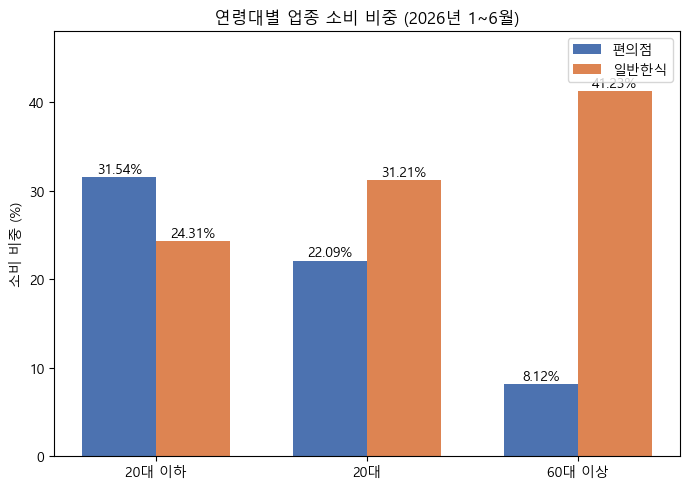

In [6]:
import numpy as np
import matplotlib.pyplot as plt
age_groups = ['20대 이하', '20대', '60대 이상']
convenience = [31.54, 22.09, 8.12]
korean_food = [24.31, 31.21, 41.23]

x = np.arange(len(age_groups))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width/2, convenience, width, label='편의점', color='#4C72B0')
bars2 = ax.bar(x + width/2, korean_food, width, label='일반한식', color='#DD8452')

for bars in [bars1, bars2]:
    for b in bars:
        h = b.get_height()
        ax.annotate(f'{h:.2f}%', xy=(b.get_x() + b.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=10)

ax.set_ylabel('소비 비중 (%)')
ax.set_title('연령대별 업종 소비 비중 (2026년 1~6월)')
ax.set_xticks(x)
ax.set_xticklabels(age_groups)
ax.legend()
ax.set_ylim(0, 48)
plt.tight_layout()
plt.show()

In [4]:
import matplotlib.font_manager as fm

# 설치된 폰트 중 한글 관련 폰트 전부 찾기
korean_fonts = [f.name for f in fm.fontManager.ttflist 
                if any(k in f.name for k in ['Gothic', 'Malgun', 'Nanum', 'Batang', 'Dotum', 'Gulim'])]
print(set(korean_fonts))

{'Han Santteut Dotum', 'HCR Batang ExtB', 'Gulim', 'Franklin Gothic Heavy', 'Hancom Gothic', 'Copperplate Gothic Light', 'Batang', 'KoPubWorldBatang_Pro', 'HCR Dotum', 'Franklin Gothic Medium Cond', 'Century Gothic', 'Franklin Gothic Demi', 'Copperplate Gothic Bold', 'HCR Batang', 'Franklin Gothic Demi Cond', 'Franklin Gothic Medium', 'NanumGothic', 'Malgun Gothic', 'HCR Dotum Ext', 'HCR Batang Ext', 'Showcard Gothic', 'Yu Gothic', 'Franklin Gothic Book', 'MS Gothic'}


In [5]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

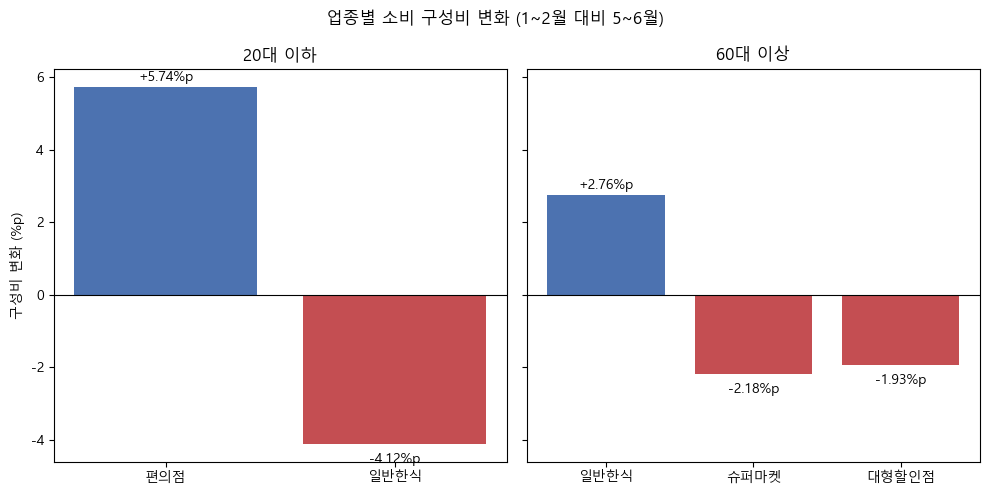

In [7]:
labels_20 = ['편의점', '일반한식']
values_20 = [5.74, -4.12]

labels_60 = ['일반한식', '슈퍼마켓', '대형할인점']
values_60 = [2.76, -2.18, -1.93]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

colors_20 = ['#4C72B0' if v > 0 else '#C44E52' for v in values_20]
axes[0].bar(labels_20, values_20, color=colors_20)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('20대 이하')
axes[0].set_ylabel('구성비 변화 (%p)')
for i, v in enumerate(values_20):
    axes[0].annotate(f'{v:+.2f}%p', xy=(i, v), xytext=(0, 4 if v > 0 else -14),
                      textcoords='offset points', ha='center', fontsize=10)

colors_60 = ['#4C72B0' if v > 0 else '#C44E52' for v in values_60]
axes[1].bar(labels_60, values_60, color=colors_60)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('60대 이상')
for i, v in enumerate(values_60):
    axes[1].annotate(f'{v:+.2f}%p', xy=(i, v), xytext=(0, 4 if v > 0 else -14),
                      textcoords='offset points', ha='center', fontsize=10)

fig.suptitle('업종별 소비 구성비 변화 (1~2월 대비 5~6월)')
plt.tight_layout()
plt.show()

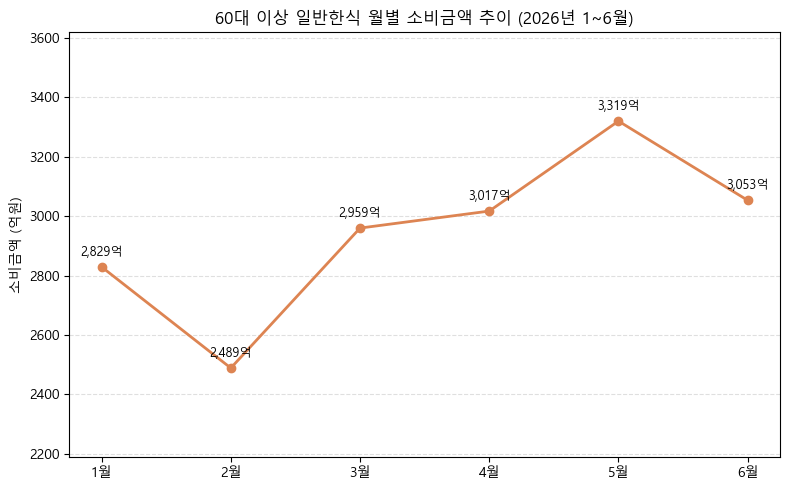

In [8]:
months = ['1월', '2월', '3월', '4월', '5월', '6월']
amt_billion_won = [282.89544, 248.89053, 295.94406, 301.66124, 331.90794, 305.27511]
amt_100m_won = [v * 10 for v in amt_billion_won]  # 억원 환산

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(months, amt_100m_won, marker='o', linewidth=2, color='#DD8452')

for i, v in enumerate(amt_100m_won):
    ax.annotate(f'{v:,.0f}억', xy=(i, v), xytext=(0, 8),
                textcoords='offset points', ha='center', fontsize=9)

ax.set_ylabel('소비금액 (억원)')
ax.set_title('60대 이상 일반한식 월별 소비금액 추이 (2026년 1~6월)')
ax.set_ylim(min(amt_100m_won) - 300, max(amt_100m_won) + 300)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

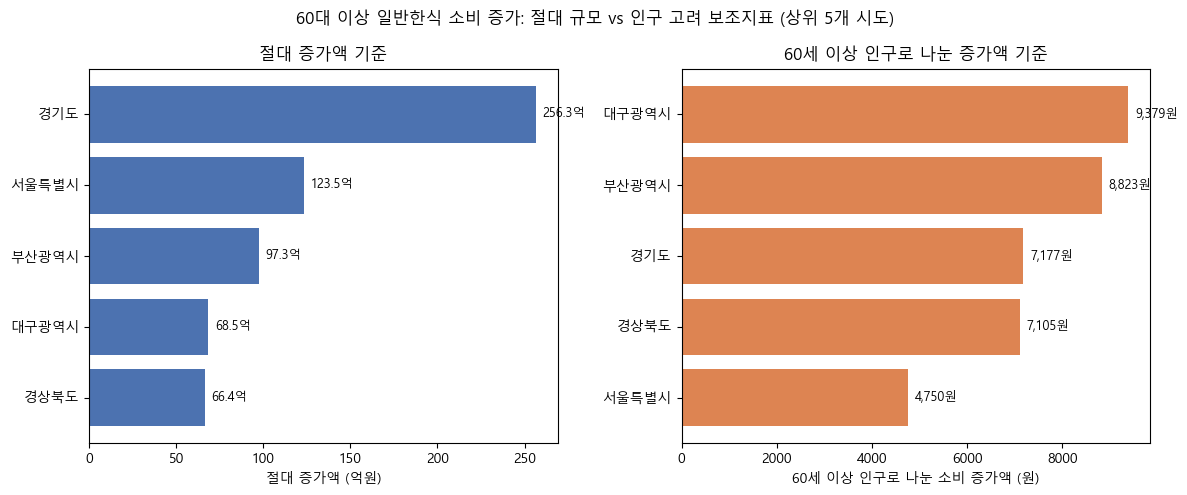

In [9]:
sido = ['경기도', '서울특별시', '부산광역시', '대구광역시', '경상북도']
abs_increase = [256.3, 123.5, 97.3, 68.5, 66.4]
per_capita = [7177, 4750, 8823, 9379, 7105]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

order1 = np.argsort(abs_increase)[::-1]
axes[0].barh([sido[i] for i in order1], [abs_increase[i] for i in order1], color='#4C72B0')
axes[0].set_xlabel('절대 증가액 (억원)')
axes[0].set_title('절대 증가액 기준')
axes[0].invert_yaxis()
for i, v in enumerate([abs_increase[i] for i in order1]):
    axes[0].annotate(f'{v:.1f}억', xy=(v, i), xytext=(5, 0), textcoords='offset points', va='center', fontsize=9)

order2 = np.argsort(per_capita)[::-1]
axes[1].barh([sido[i] for i in order2], [per_capita[i] for i in order2], color='#DD8452')
axes[1].set_xlabel('60세 이상 인구로 나눈 소비 증가액 (원)')
axes[1].set_title('60세 이상 인구로 나눈 증가액 기준')
axes[1].invert_yaxis()
for i, v in enumerate([per_capita[i] for i in order2]):
    axes[1].annotate(f'{v:,}원', xy=(v, i), xytext=(5, 0), textcoords='offset points', va='center', fontsize=9)

fig.suptitle('60대 이상 일반한식 소비 증가: 절대 규모 vs 인구 고려 보조지표 (상위 5개 시도)')
plt.tight_layout()
plt.show()

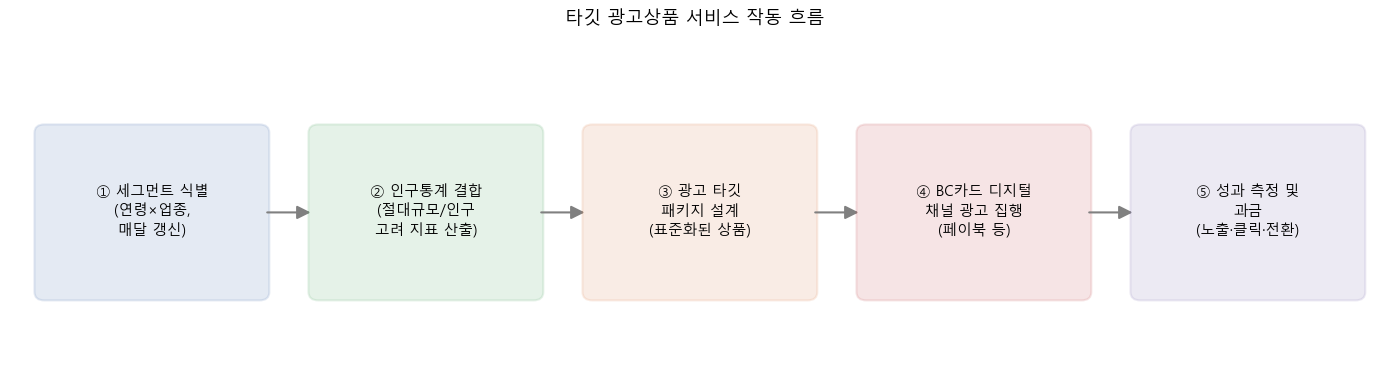

In [10]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

steps = [
    "① 세그먼트 식별\n(연령×업종,\n매달 갱신)",
    "② 인구통계 결합\n(절대규모/인구\n고려 지표 산출)",
    "③ 광고 타깃\n패키지 설계\n(표준화된 상품)",
    "④ BC카드 디지털\n채널 광고 집행\n(페이북 등)",
    "⑤ 성과 측정 및\n과금\n(노출·클릭·전환)",
]

fig, ax = plt.subplots(figsize=(14, 4))
ax.set_xlim(0, 14)
ax.set_ylim(0, 4)
ax.axis('off')

box_w, box_h = 2.3, 2.0
gap = 0.5
start_x = 0.3
y = 1.0
colors = ['#4C72B0', '#55A868', '#DD8452', '#C44E52', '#8172B2']

for i, (step, color) in enumerate(zip(steps, colors)):
    x = start_x + i * (box_w + gap)
    box = FancyBboxPatch((x, y), box_w, box_h, boxstyle="round,pad=0.05,rounding_size=0.1",
                          linewidth=1.5, edgecolor=color, facecolor=color, alpha=0.15)
    ax.add_patch(box)
    ax.text(x + box_w/2, y + box_h/2, step, ha='center', va='center', fontsize=10.5, linespacing=1.4)
    if i < len(steps) - 1:
        arrow = FancyArrowPatch((x + box_w, y + box_h/2), (x + box_w + gap, y + box_h/2),
                                 arrowstyle='-|>', mutation_scale=20, color='gray', linewidth=1.5)
        ax.add_patch(arrow)

ax.set_title('타깃 광고상품 서비스 작동 흐름', fontsize=13, pad=15)
plt.tight_layout()
plt.show()